In [1]:
import yt 
import numpy as np

def _gamma(field, data):
    u1 = data[('gas', 'four_velocity_r')]
    u2 = data[('gas', 'four_velocity_theta')]
    u3 = data[('gas', 'four_velocity_z')]
    c = data.ds.quan(1.0, 'code_velocity')
    return (1 + (u1/c)**2 + (u2/c)**2 + (u3/c)**2)**0.5


yt.add_field(('gas', 'lorentz_gamma'), function=_gamma, units="", sampling_type = "cell", dimensions = yt.units.dimensionless)
# Cartesian velocity components derived directly from the native cylindrical fields.
# ('athena_pp', 'vel1') = v_R,  ('athena_pp', 'vel2') = v_phi
# ('index', 'theta')    = azimuthal angle phi of each cell
# v_x = v_R*cos(phi) - v_phi*sin(phi)
# v_y = v_R*sin(phi) + v_phi*cos(phi)
def _vel_cyl_x(field, data):
    phi  = data[('index', 'theta')]
    vr   = data[('athena_pp', 'vel1')]
    vphi = data[('athena_pp', 'vel2')]
    return vr * np.cos(phi) - vphi * np.sin(phi)

def _vel_cyl_y(field, data):
    phi  = data[('index', 'theta')]
    vr   = data[('athena_pp', 'vel1')]
    vphi = data[('athena_pp', 'vel2')]
    return vr * np.sin(phi) + vphi * np.cos(phi)

yt.add_field(('gas', 'vel_cyl_x'), function=_vel_cyl_x,
             units='code_velocity', sampling_type='cell', force_override=True)
yt.add_field(('gas', 'vel_cyl_y'), function=_vel_cyl_y,
             units='code_velocity', sampling_type='cell', force_override=True)

In [2]:
def _enthalpy(field, data):
    rho = data[('athena_pp', 'rho')]
    P = data[('athena_pp', 'press')]
    c = data.ds.quan(1.0, 'code_velocity')
    return 1 + 4*P/(rho*c**2)


yt.add_field(('gas', 'enthalpy'), function=_enthalpy, units="", sampling_type="cell", dimensions=yt.units.dimensionless)

def _entropy(field, data):
    rho = data[('athena_pp', 'rho')]
    P = data[('athena_pp', 'press')]
    c = data.ds.quan(1.0, 'code_velocity')
    return P/rho**(4/3)

yt.add_field(('gas', 'entropy'), function=_entropy, units="code_length**3/(code_mass**(1/3)*code_time**2)", sampling_type="cell")

# Entropy Tracking

yt : [WARNING  ] 2026-05-29 14:49:06,561 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-05-29 14:49:06,562 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-05-29 14:49:06,563 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-05-29 14:49:06,563 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-05-29 14:49:06,602 Parameters: current_time              = 0.6300002622196839
yt : [INFO     ] 2026-05-29 14:49:06,602 Parameters: domain_dimensions         = [1200  800    1]
yt : [INFO     ] 2026-05-29 14:49:06,602 Parameters: domain_left_edge          = [0.001 0.    0.   ]
yt : [INFO     ] 2026-05-29 14:49:06,602 Parameters: domain_right_edge         = [1.5        6.28318531 1.        ]
yt : [INFO     ] 2026-05-29 14:49:06,603 Parameters: cosmological_simulation   = 0


Shock fronts at theta=4.712 rad: 1.002 R_*
Shock fronts at theta=4.695 rad: 1.002 R_*
Shock fronts at theta=4.677 rad: 1.002 R_*
Shock fronts at theta=4.660 rad: 1.002 R_*
Shock fronts at theta=4.642 rad: 1.002 R_*
Shock fronts at theta=4.625 rad: 1.002 R_*
Shock fronts at theta=4.607 rad: 1.002 R_*
Shock fronts at theta=4.590 rad: 1.002 R_*
Shock fronts at theta=4.572 rad: 1.002 R_*
Shock fronts at theta=4.554 rad: 1.002 R_*
Shock fronts at theta=4.537 rad: 1.002 R_*
Shock fronts at theta=4.519 rad: 1.002 R_*
Shock fronts at theta=4.502 rad: 1.002 R_*
Shock fronts at theta=4.484 rad: 1.002 R_*
Shock fronts at theta=4.467 rad: 1.002 R_*
Shock fronts at theta=4.449 rad: 1.002 R_*
Shock fronts at theta=4.432 rad: 1.002 R_*
Shock fronts at theta=4.414 rad: 1.002 R_*
Shock fronts at theta=4.396 rad: 1.002 R_*
Shock fronts at theta=4.379 rad: 1.002 R_*
Shock fronts at theta=4.361 rad: 1.002 R_*
Shock fronts at theta=4.344 rad: 1.002 R_*
Shock fronts at theta=4.326 rad: 1.002 R_*
Shock front

/tmp/ipykernel_2599414/66237490.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


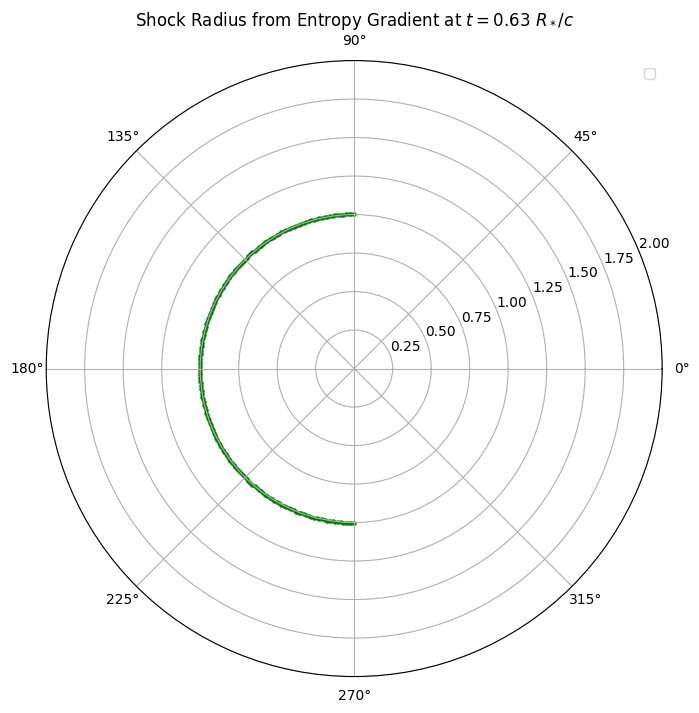

yt : [INFO     ] 2026-05-29 14:49:10,393 xlim = -1.500000 1.500000
yt : [INFO     ] 2026-05-29 14:49:10,393 ylim = -1.500000 1.500000
yt : [INFO     ] 2026-05-29 14:49:10,394 Setting origin='native' for cylindrical geometry.
yt : [INFO     ] 2026-05-29 14:49:10,395 xlim = -1.500000 1.500000
yt : [INFO     ] 2026-05-29 14:49:10,396 ylim = -1.500000 1.500000
yt : [INFO     ] 2026-05-29 14:49:10,398 Making a fixed resolution buffer of (('gas', 'entropy')) 800 by 800



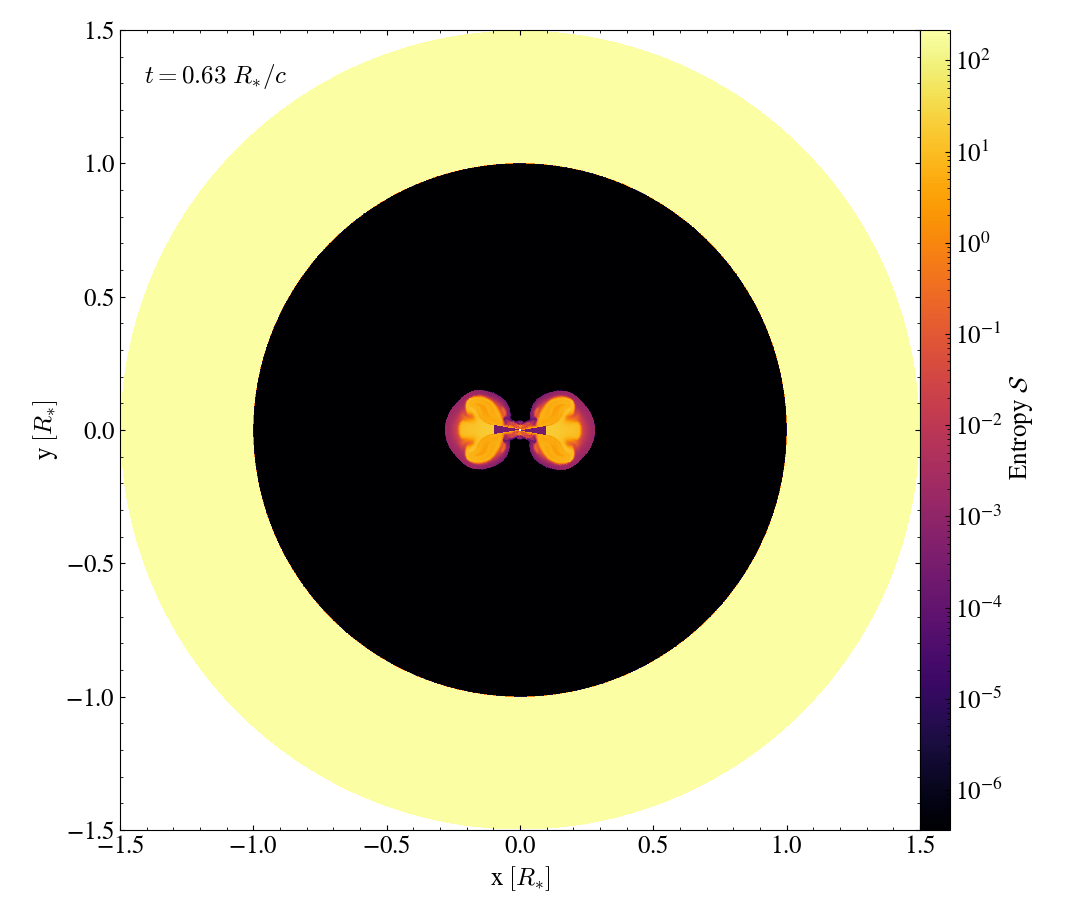

In [ ]:
import yt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# 1D velocity profile at a fixed azimuthal angle
theta_vals = np.linspace(3*np.pi/2, np.pi/2, 180)  # example theta values
z_val     = 0.5   #doesnt matter

ds_entr = yt.load('/scratch/aripoll/athena_out/outputs/jet_blast.out1.00630.athdf')


r_shock_entropy = []  # list of lists: 1 or more radii per theta

for theta_val in theta_vals:
    ray = ds_entr.ortho_ray(0, (theta_val, z_val))

    df_entr = ray.to_dataframe([('index', 'r'), ('gas', 'entropy')])
    df_entr = df_entr.sort_values('r').reset_index(drop=True)

    if len(df_entr) < 2:
        r_shock_entropy.append([np.nan])
        continue

    # Shock has hit the surface: outer boundary entropy is still unshocked
    if np.log10(df_entr['entropy'].iloc[-1]) < 1:
        r_shock_entropy.append([1.5])
        print(f"Shock at boundary for theta={theta_val:.3f} rad")
        continue

    dlogS_dr = np.gradient(np.log10(df_entr['entropy']), df_entr['r'])
    abs_grad = np.abs(dlogS_dr)

    peaks, _ = find_peaks(abs_grad, height=100, distance=10)
    peak_radii = sorted(
        [float(df_entr['r'].iloc[i]) for i in peaks if df_entr['r'].iloc[i] > 0.2],
        reverse=True
    )

    max_distance = 0.3  # tune: max allowed distance from outermost shock front

    selected = []
    if peak_radii:
        r_outer = peak_radii[0]
        selected = [r for r in peak_radii if r_outer - r <= max_distance]

    # Separately keep stellar surface peak near R=1.0
    surface_peaks = [r for r in peak_radii if 0.85 < r < 1.15]
    if surface_peaks and (not selected or min(abs(s - 1.0) for s in selected) > 0.1):
        selected.append(min(surface_peaks, key=lambda r: abs(r - 1.0)))

    radii = sorted(selected)
    if radii:
        print(f"Shock fronts at theta={theta_val:.3f} rad: {', '.join(f'{r:.3f}' for r in radii)} R_*")
        r_shock_entropy.append(radii)
    else:
        r_shock_entropy.append([np.nan])
    # fig, ax = plt.subplots()
    # ax.plot(df_entr['r'], df_entr['entropy'], label='Entropy')
    # ax.plot(df_entr['r'], abs_grad, label='|dlogS/dr|', alpha=0.5)
    # for r in radii:
    #     ax.axvline(r, color='r', linestyle='--', label=f'shock r={r:.3f}')
    # ax.set_xlabel(r"$r \ [R_*]$")
    # ax.set_ylabel(r"Entropy $\mathcal{S}$")
    # ax.set_title(rf"Entropy at $\theta = {theta_val*180/np.pi:.3f}$°, $t = {float(ds_entr.current_time):.2f}\ R_*/c$") 
    # ax.legend()
    # plt.show()

# Flatten for polar plot: duplicate theta for entries with two fronts
plot_theta = [th for th, rs in zip(theta_vals, r_shock_entropy) for _ in rs]
plot_r     = [r  for rs in r_shock_entropy for r in rs]

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(12, 8))
ax.scatter(plot_theta, plot_r, marker='o', color='g', s=5)
ax.set_rlim(0, 2)
ax.set_title(rf"Shock Radius from Entropy Gradient at $t = {float(ds_entr.current_time):.2f}\ R_*/c$")
ax.legend()
plt.show()

p = yt.SlicePlot(ds_entr, 'z', ('gas', 'entropy'))
p.annotate_timestamp(corner="upper_left", text_args={"color": "black"}, time_format=r"$t = {time:.2f}\ R_{{*}}/c$")
p.set_cmap(("gas", "entropy"), "inferno")
p.set_xlabel(r"x $[R_{*}]$")
p.set_ylabel(r"y $[R_{*}]$")
p.set_colorbar_label(("gas", "entropy"), r" Entropy $\mathcal{S}$")

# Lorentz Factor tracking

yt : [WARNING  ] 2026-05-29 14:49:11,356 Assuming 1.0 = 1.0 cm
yt : [WARNING  ] 2026-05-29 14:49:11,357 Assuming 1.0 = 1.0 s
yt : [WARNING  ] 2026-05-29 14:49:11,357 Assuming 1.0 = 1.0 g
yt : [WARNING  ] 2026-05-29 14:49:11,357 Assuming 1.0 = 1.0 K
yt : [INFO     ] 2026-05-29 14:49:11,383 Parameters: current_time              = 0.9000013308920282
yt : [INFO     ] 2026-05-29 14:49:11,383 Parameters: domain_dimensions         = [1200  800    1]
yt : [INFO     ] 2026-05-29 14:49:11,384 Parameters: domain_left_edge          = [0.001 0.    0.   ]
yt : [INFO     ] 2026-05-29 14:49:11,384 Parameters: domain_right_edge         = [1.5        6.28318531 1.        ]
yt : [INFO     ] 2026-05-29 14:49:11,384 Parameters: cosmological_simulation   = 0


Shock fronts at theta=0.386 rad: 0.203 R_*
Shock fronts at theta=0.421 rad: 0.211 R_*
Shock fronts at theta=0.527 rad: 0.238 R_*
Shock fronts at theta=0.562 rad: 0.239 R_*
Shock fronts at theta=0.597 rad: 0.239 R_*
Shock fronts at theta=0.632 rad: 0.236 R_*
Shock fronts at theta=0.667 rad: 0.225 R_*
Shock fronts at theta=2.492 rad: 0.233 R_*
Shock fronts at theta=2.527 rad: 0.238 R_*
Shock fronts at theta=2.562 rad: 0.239 R_*
Shock fronts at theta=2.598 rad: 0.239 R_*
Shock fronts at theta=2.703 rad: 0.215 R_*
Shock fronts at theta=2.738 rad: 0.206 R_*
Shock fronts at theta=3.545 rad: 0.206 R_*
Shock fronts at theta=3.580 rad: 0.215 R_*
Shock fronts at theta=3.686 rad: 0.239 R_*
Shock fronts at theta=3.721 rad: 0.239 R_*
Shock fronts at theta=3.756 rad: 0.238 R_*
Shock fronts at theta=3.791 rad: 0.233 R_*
Shock fronts at theta=5.616 rad: 0.225 R_*
Shock fronts at theta=5.651 rad: 0.236 R_*
Shock fronts at theta=5.686 rad: 0.239 R_*
Shock fronts at theta=5.722 rad: 0.239 R_*
Shock front

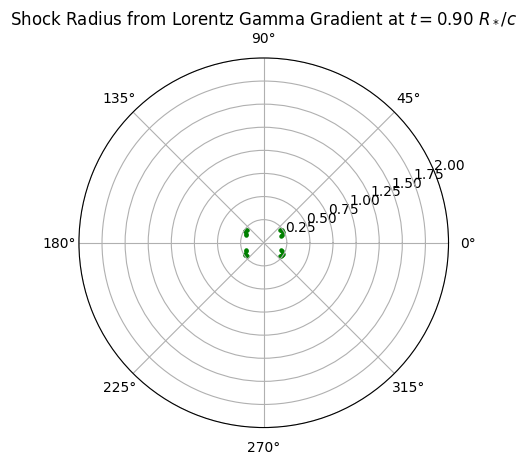

yt : [INFO     ] 2026-05-29 14:49:14,360 xlim = -1.500000 1.500000
yt : [INFO     ] 2026-05-29 14:49:14,360 ylim = -1.500000 1.500000
yt : [INFO     ] 2026-05-29 14:49:14,361 Setting origin='native' for cylindrical geometry.
yt : [INFO     ] 2026-05-29 14:49:14,362 xlim = -1.500000 1.500000
yt : [INFO     ] 2026-05-29 14:49:14,363 ylim = -1.500000 1.500000
yt : [INFO     ] 2026-05-29 14:49:14,363 Making a fixed resolution buffer of (('gas', 'lorentz_gamma')) 800 by 800



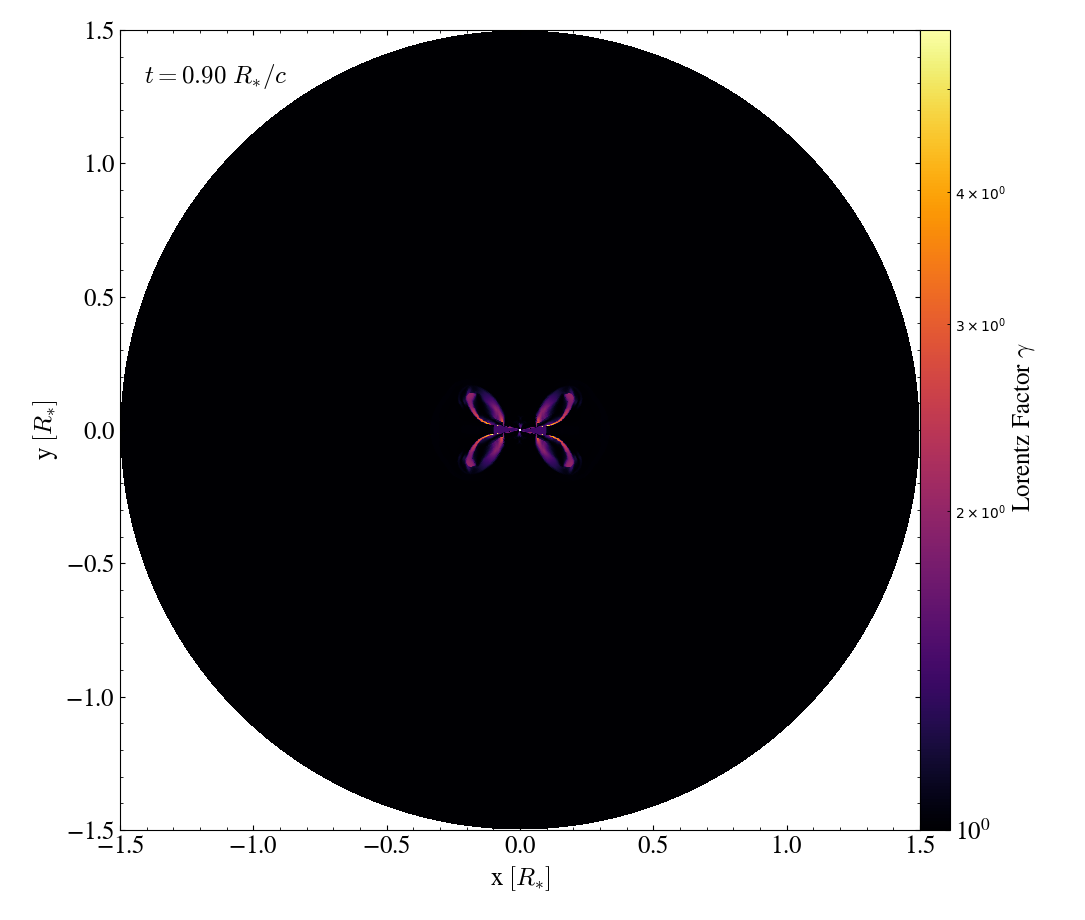

In [5]:
ds_gamma = yt.load('/scratch/aripoll/athena_out/outputs/jet_blast.out1.00900.athdf')

theta_vals = np.linspace(0, 2*np.pi, 180)  # example theta values

radii_gamma = []  # one entry per theta_val: list of radii or [nan]


for theta_val in theta_vals:
    ray = ds_gamma.ortho_ray(0, (theta_val, z_val))
    df_gamma = ray.to_dataframe([('index', 'r'), ('gas', 'lorentz_gamma')])
    df_gamma = df_gamma.sort_values('r').reset_index(drop=True)

    if len(df_gamma) < 2:
        radii_gamma.append([np.nan])  # was: bare continue (bug 1)
        continue

    dgamma_dr = np.gradient(df_gamma['lorentz_gamma'], df_gamma['r'])
    abs_grad = np.abs(dgamma_dr)

    peaks, _ = find_peaks(abs_grad, height=100, distance=10)
    radii = [float(df_gamma['r'].iloc[i]) for i in peaks if df_gamma['r'].iloc[i] > 0.2]

    if radii:
        print(f"Shock fronts at theta={theta_val:.3f} rad: {', '.join(f'{r:.3f}' for r in radii)} R_*")
        radii_gamma.append(radii)
    else:
        radii_gamma.append([np.nan])  # was: nothing (bug 2)

    # fig, ax = plt.subplots()
    # ax.plot(df_gamma['r'], df_gamma['lorentz_gamma'], label='Lorentz Gamma')
    # ax.plot(df_gamma['r'], dgamma_dr, label='dGamma/dr', alpha=0.5)
    # for r in radii:
    #     ax.axvline(r, color='r', linestyle='--', label=f'shock r={r:.3f}')
    # ax.set_xlabel(r"$r \ [R_*]$")
    # ax.set_ylabel(r"Lorentz Factor $\gamma$")
    # ax.set_title(rf"Lorentz Factor at $\theta = {theta_val*180/np.pi:.3f}$°, $t = {float(ds_gamma.current_time):.2f}\ R_*/c$")
    # ax.legend()
    # plt.show()

# Flatten using zip so theta tracks actual detection angles (bug 3 fix)
plot_theta = [th for th, rs in zip(theta_vals, radii_gamma) for _ in rs]
plot_r     = [r  for rs in radii_gamma for r in rs]

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.scatter(plot_theta, plot_r, marker='o', color='g', s=5)
ax.set_rlim(0, 2)
ax.set_title(rf"Shock Radius from Lorentz Gamma Gradient at $t = {float(ds_gamma.current_time):.2f}\ R_*/c$")
plt.show()

p = yt.SlicePlot(ds_gamma, 'z', ('gas', 'lorentz_gamma'))
p.annotate_timestamp(corner="upper_left", text_args={"color": "black"}, time_format=r"$t = {time:.2f}\ R_{{*}}/c$")
p.set_cmap(("gas", "lorentz_gamma"), "inferno")
p.set_xlabel(r"x $[R_{*}]$")
p.set_ylabel(r"y $[R_{*}]$")
p.set_colorbar_label(("gas", "lorentz_gamma"), r" Lorentz Factor $\gamma$")


# The in-sim tracking

Requested t=2.6000, using t=2.5996  (421 fronts)


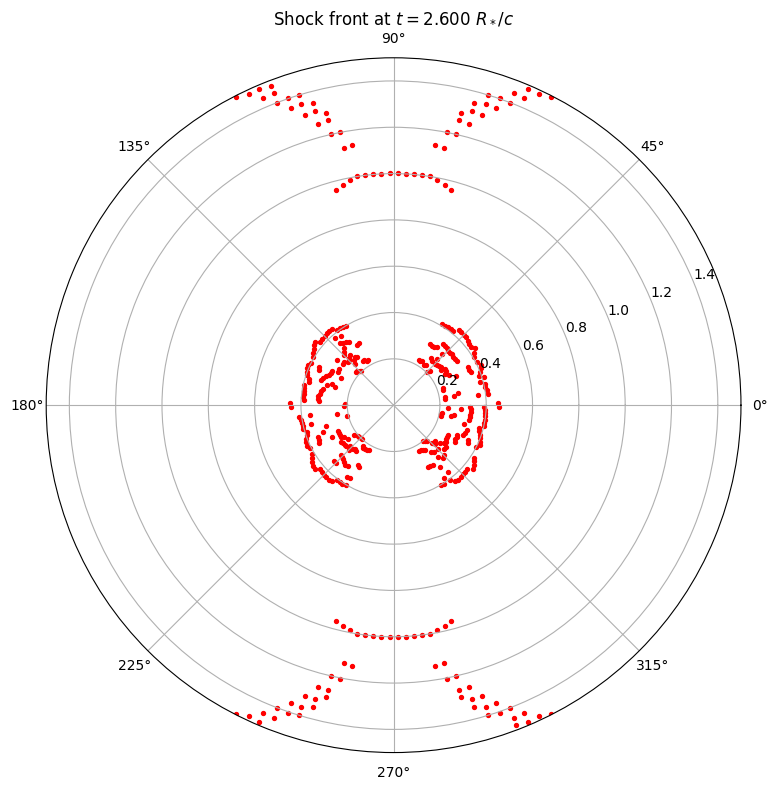

,angle_deg,r_shock,vr,v_tang
time,,,,
2.59964,1,0.450407,0.808205,-0.472644
2.59964,7,0.412347,0.481675,-0.484743
2.59964,7,0.368431,0.101582,0.053235
2.59964,7,0.222044,0.086144,-0.085771
2.59964,9,0.406491,0.414131,-0.555896
...,...,...,...,...
2.59964,357,0.292310,0.304568,0.327302
2.59964,357,0.236683,0.186151,-0.133082
2.59964,359,0.453335,0.714586,-0.399286


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fronts = pd.read_csv('/scratch/aripoll/athena_out/outputs/shock_front.csv', index_col=0)

def get_fronts_at(t):
    """Return shock front rows at the timestep closest to t."""
    times = fronts.index.unique()
    closest_t = times[np.argmin(np.abs(times - t))]
    df = fronts.loc[[closest_t]]
    print(f"Requested t={t:.4f}, using t={closest_t:.4f}  ({len(df)} fronts)")
    return df

def plot_fronts_at(t):
    df = get_fronts_at(t)
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))
    ax.scatter(np.deg2rad(df['angle_deg']), df['r_shock'], marker='o', s=8, c='red')
    ax.set_rlim(0, 1.5)
    ax.set_title(rf"Shock front at $t = {df.index[0]:.3f}\ R_*/c$")
    plt.tight_layout()
    plt.show()
    return df

# --- usage: change t_query to inspect any time ---
t_query = 2.6
df = plot_fronts_at(t_query)
df

Requested t=1.8000, using t=1.8004  (232 fronts)


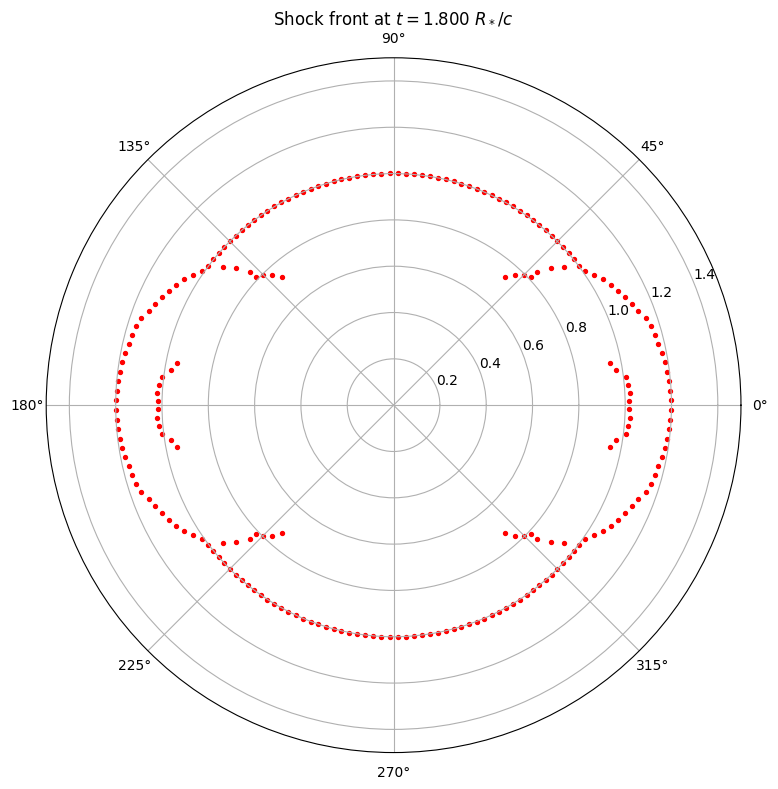

Requested t=2.1000, using t=2.0995  (224 fronts)


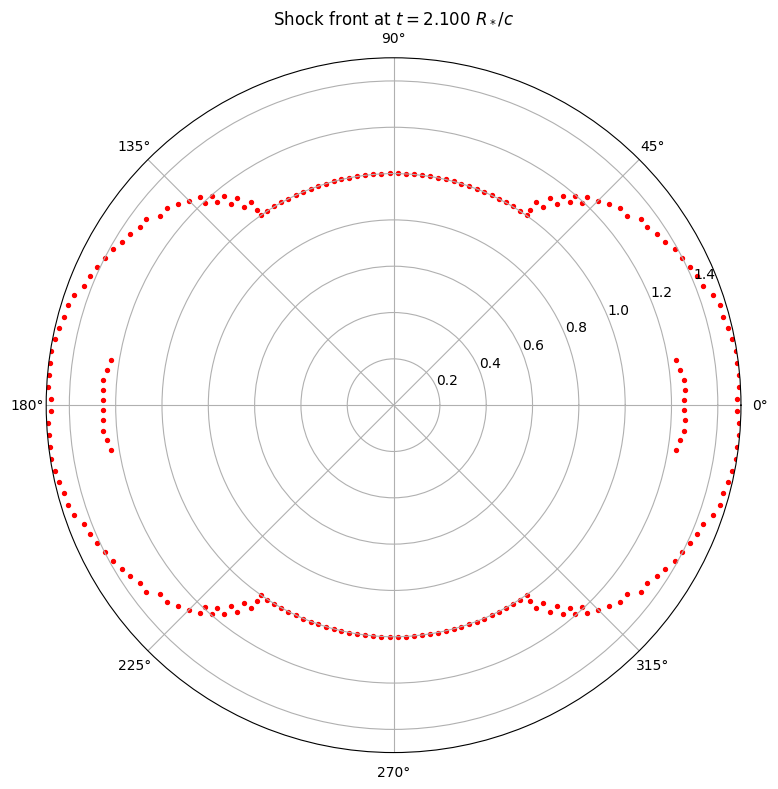

Requested t=2.4000, using t=2.3996  (313 fronts)


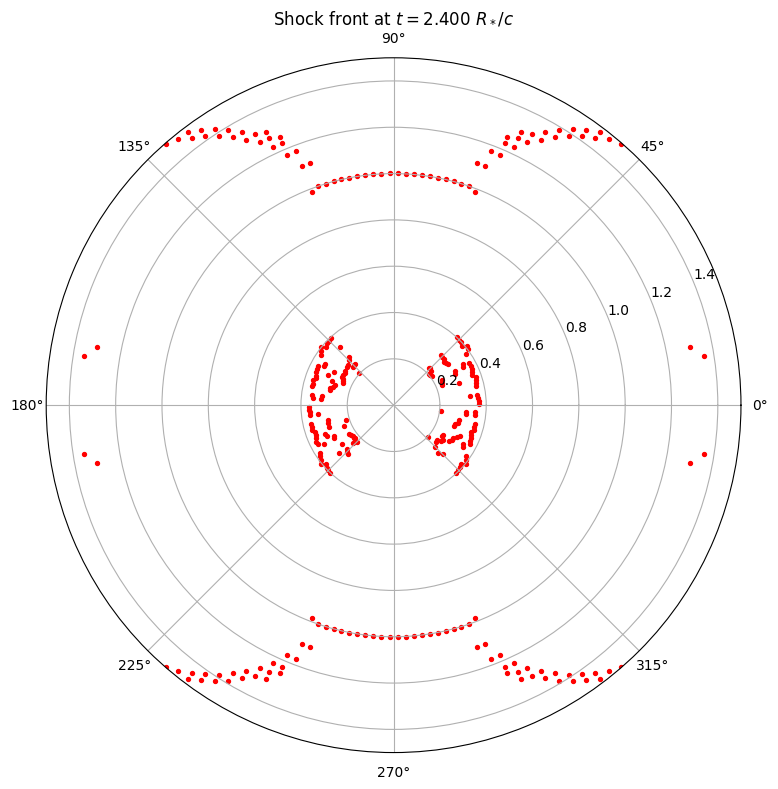

Requested t=2.7000, using t=2.6997  (443 fronts)


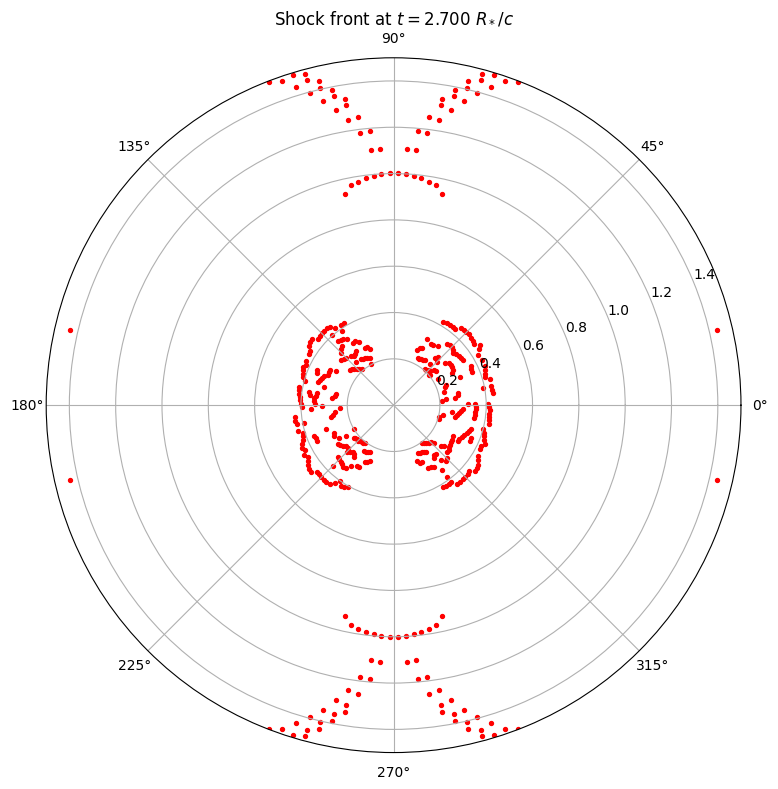

Requested t=3.0000, using t=2.9997  (369 fronts)


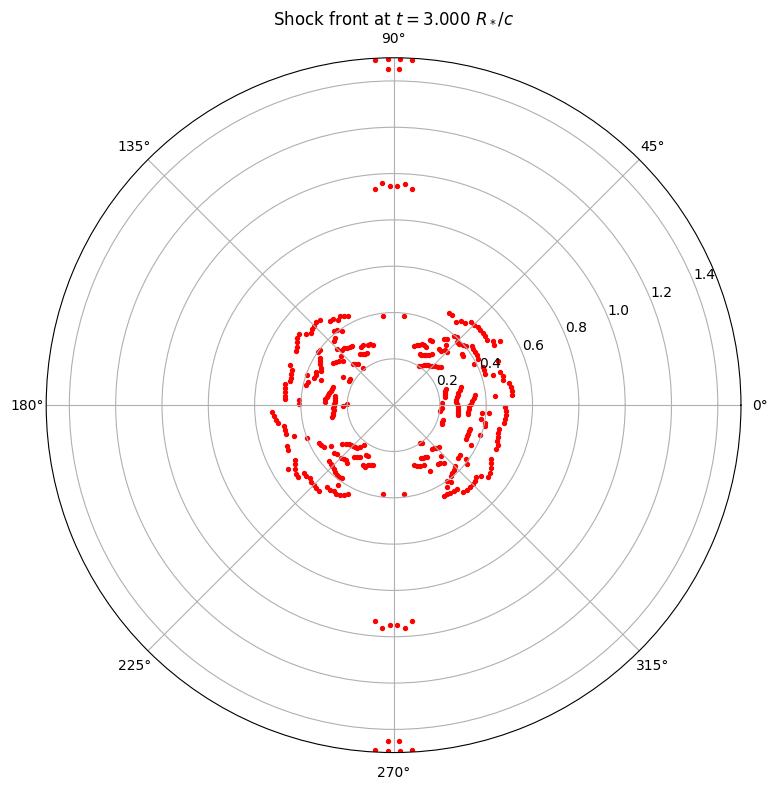

Requested t=3.3000, using t=3.2998  (330 fronts)


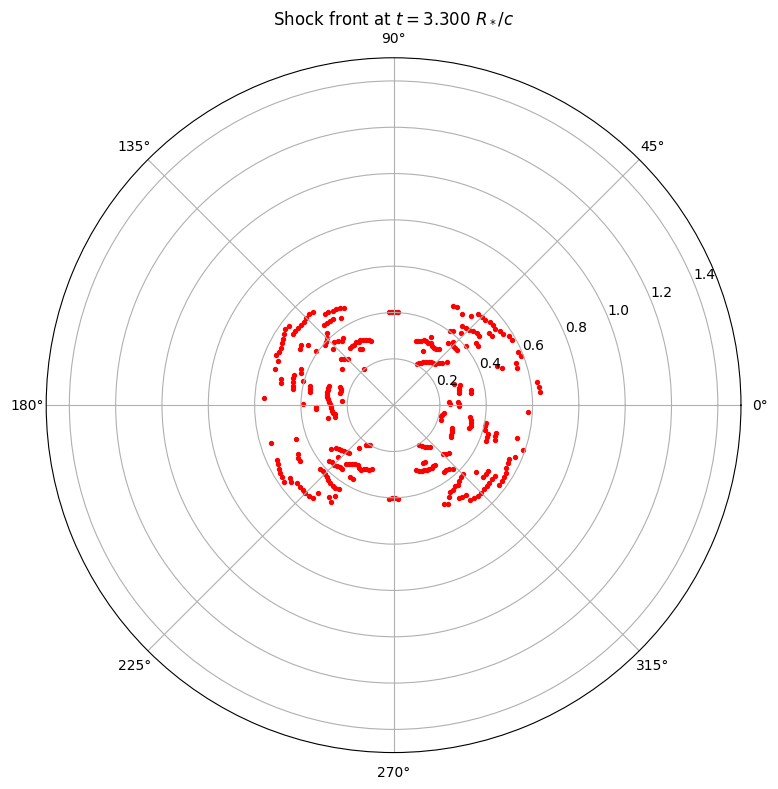

Requested t=3.6000, using t=3.5999  (294 fronts)


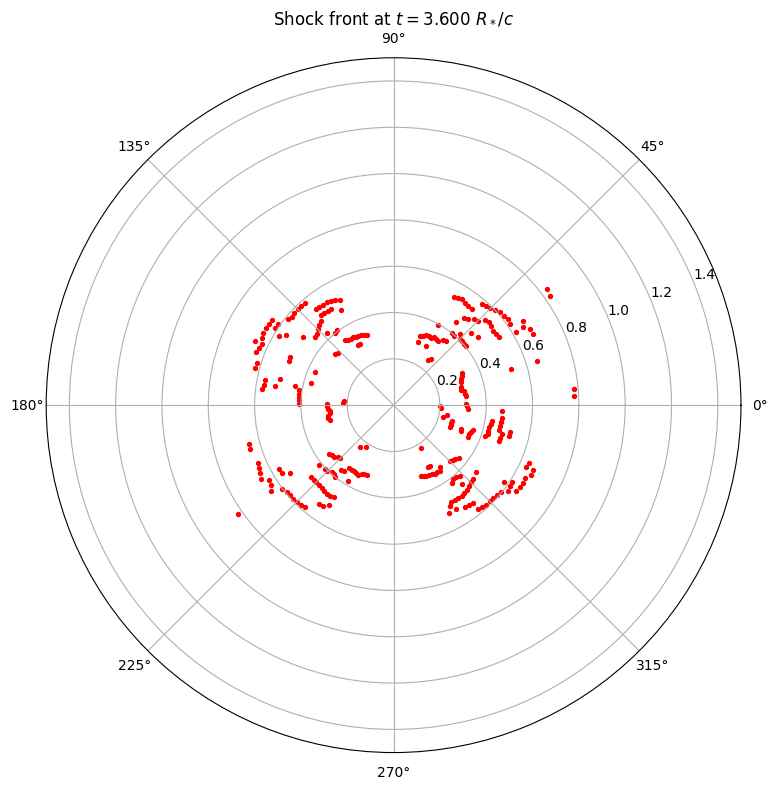

Requested t=3.9000, using t=3.6479  (292 fronts)


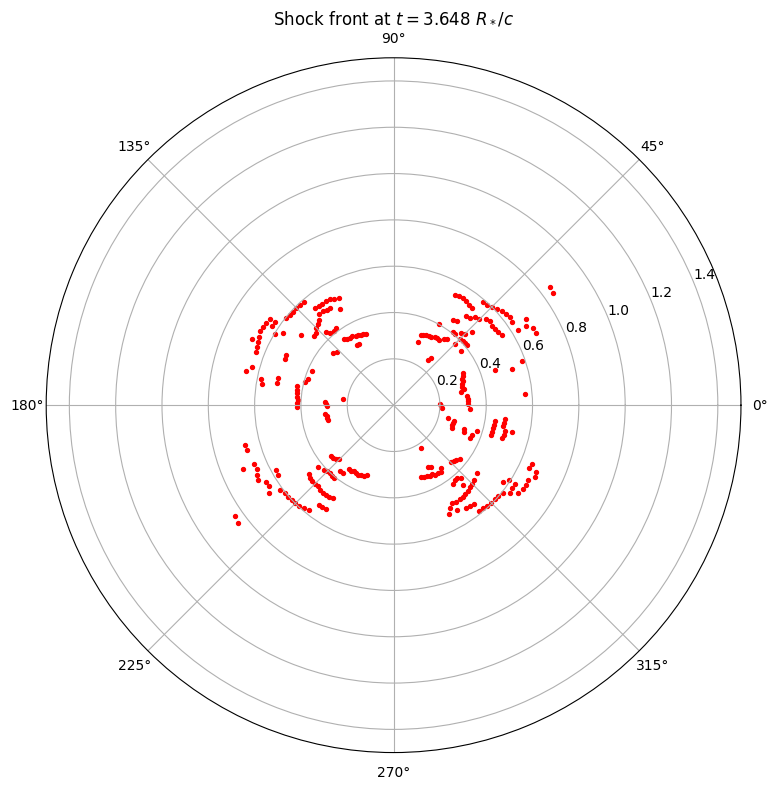

Requested t=4.2000, using t=3.6479  (292 fronts)


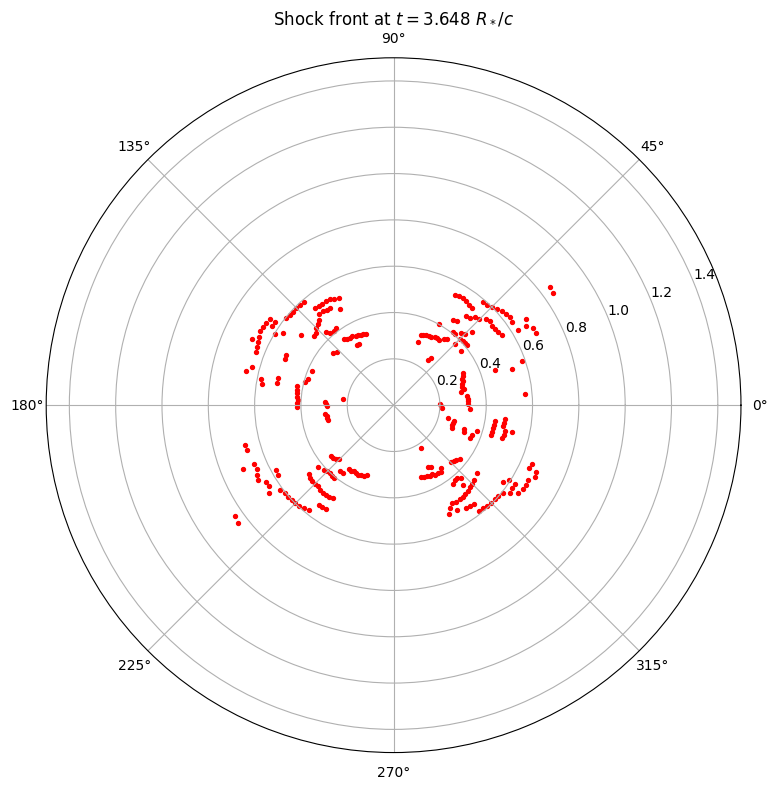

Requested t=4.5000, using t=3.6479  (292 fronts)


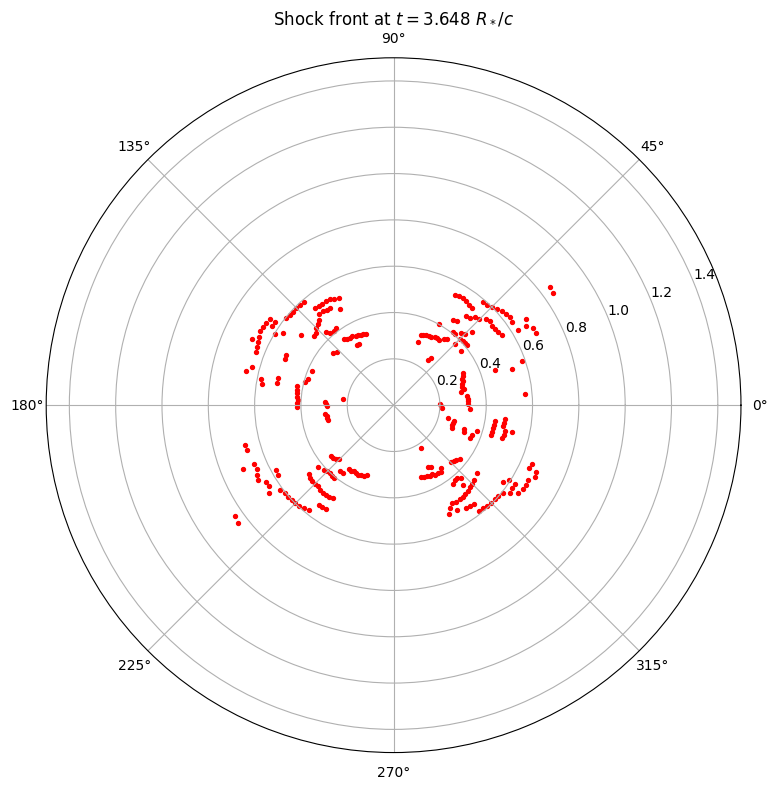

In [4]:
#Now make a movie of the shock front evolution
t = np.linspace(1.8, 4.5, 10)
for t in t:
    plot_fronts_at(t)

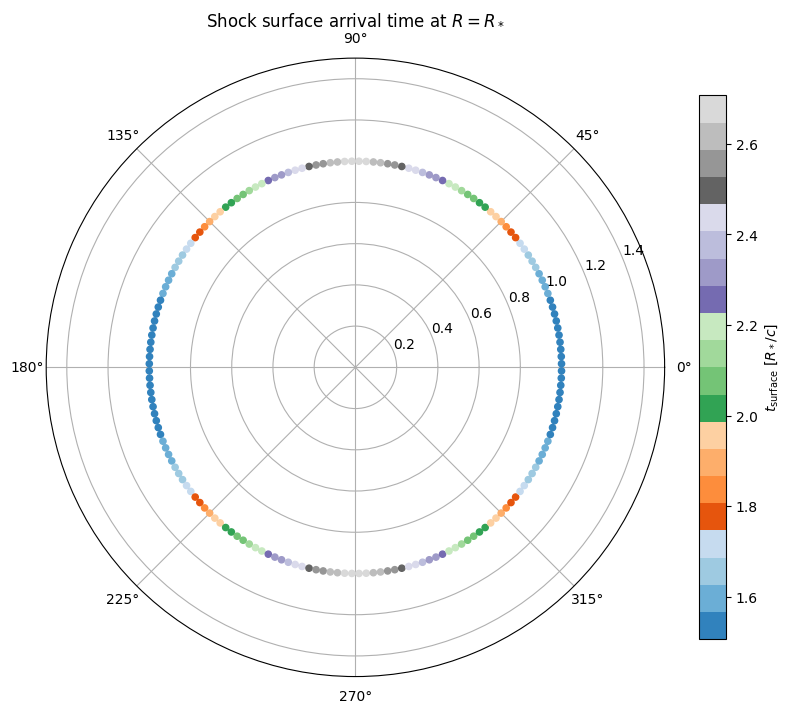

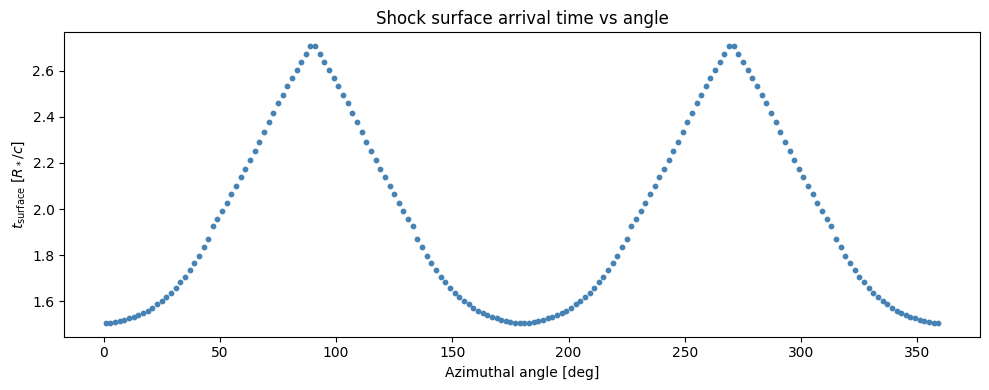

angle_deg
1      1.50637
3      1.50737
5      1.51037
7      1.51437
9      1.52037
11     1.52638
13     1.53238
15     1.54038
17     1.54938
19     1.55938
21     1.57239
23     1.58639
25     1.60240
27     1.62040
29     1.63740
31     1.65841
33     1.68241
35     1.70742
37     1.73543
39     1.76544
41     1.79744
43     1.83545
45     1.87146
47     1.92648
49     1.95848
51     1.99249
53     2.02850
55     2.06451
57     2.10052
59     2.13753
61     2.17554
63     2.21455
65     2.25055
67     2.29157
69     2.33258
71     2.37659
73     2.41860
75     2.45861
77     2.49662
79     2.53362
81     2.56963
83     2.60164
85     2.63665
87     2.67166
89     2.70667
91     2.70667
93     2.67166
95     2.63665
97     2.60164
99     2.56963
101    2.53362
103    2.49662
105    2.45861
107    2.41860
109    2.37659
111    2.33258
113    2.29157
115    2.25055
117    2.21455
119    2.17554
121    2.13753
123    2.10052
125    2.06451
127    2.02850
129    1.99249
131    1.95848


In [5]:
def shock_surface_arrival(r_tol=0.1, vr_min=0.01):
    """
    For each angular bin, find the first timestep where a shock front
    sits near R=1 with a meaningful outward radial velocity.

    r_tol  : half-window around R=1 to count as 'at the surface' [R_*]
    vr_min : minimum u^r (4-velocity) to exclude near-zero background
              (at t=0 the stellar surface already has a gradient peak but u^r~1e-7)
    """
    near_surface = fronts[
        (np.abs(fronts['r_shock'] - 1.0) < r_tol) &
        (fronts['vr'] > vr_min)
    ]
    arrival = (
        near_surface
        .reset_index()
        .groupby('angle_deg')['time']
        .min()
        .rename('t_surface')
    )
    return arrival

arrival = shock_surface_arrival(r_tol=0.1, vr_min=0.01)

# Polar plot: each angle dot coloured by arrival time
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))
sc = ax.scatter(
    np.deg2rad(arrival.index), np.ones(len(arrival)),
    c=arrival.values, cmap='tab20c', s=20, zorder=3
)
ax.set_rlim(0, 1.5)
ax.set_title(r"Shock surface arrival time at $R = R_*$")
plt.colorbar(sc, ax=ax, label=r'$t_{\rm surface}\ [R_*/c]$', fraction=0.04)
plt.tight_layout()
plt.show()

# Cartesian: angle vs arrival time (easier to read exact values)
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(arrival.index, arrival.values, s=10, c='steelblue')
ax.set_xlabel(r'Azimuthal angle [deg]')
ax.set_ylabel(r'$t_{\rm surface}\ [R_*/c]$')
ax.set_title(r'Shock surface arrival time vs angle')
plt.tight_layout()
plt.show()

print(arrival.to_string())

AttributeError: module 'matplotlib.pyplot' has no attribute 'set_font'

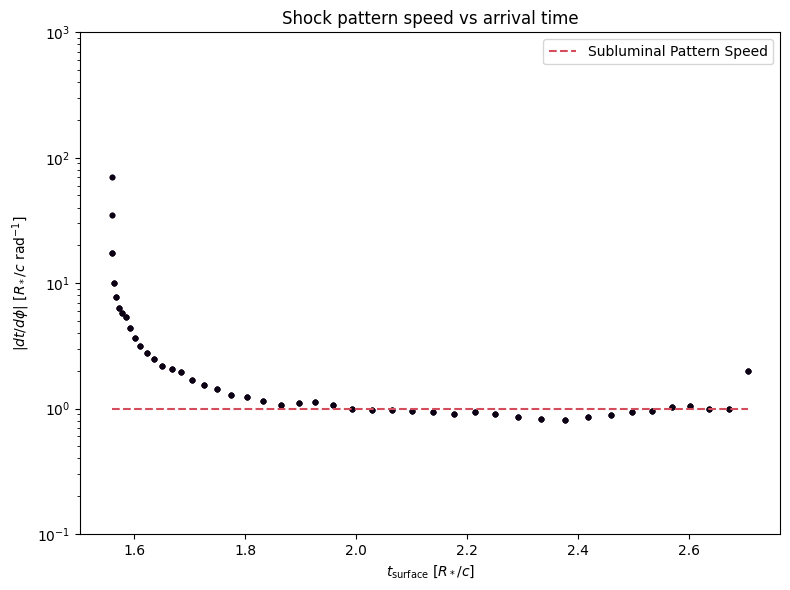

In [20]:
def surface_arrival_rows(r_tol=0.05, vr_min=0.01):
    """Full shock row (including vr, v_tang) at first surface arrival per angle."""
    near = (
        fronts[
            (np.abs(fronts['r_shock'] - 1.0) < r_tol) &
            (fronts['vr'] > vr_min)
        ]
        .reset_index()
        .sort_values('time')
    )
    return near.groupby('angle_deg').first().reset_index()

arr = surface_arrival_rows().sort_values('angle_deg').reset_index(drop=True)
phi_rad = np.deg2rad(arr['angle_deg'].values)
t_surf  = arr['time'].values

# ---- 1. Pattern speed: t_surface vs 1/speed = dt/dphi ----
dt_dphi = np.gradient(t_surf, phi_rad)          # [R_*/c per rad]
# at R=1 the linear pattern speed along the surface is dphi/dt [c]
pattern_speed = 1.0 / np.abs(dt_dphi)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
# ax.scatter(arr['angle_deg'], pattern_speed, s=10, c='steelblue')
# ax.set_xlim(0, 90)
# ax.set_yscale('log')
# ax.set_ylim(0.1, 1e3)
# ax.set_xlabel(r'$\phi\ [\mathrm{degrees}]$')
# ax.set_ylabel(r'$|dt/d\phi|\ [R_*/c\ \mathrm{rad}^{-1}]$')
# ax.set_title(r'Shock pattern speed at stellar surface — later arrivals move slower')
# ax.hlines(1.0, 0, 90, colors='red', linestyles='dashed', label='Speed of Light')
ax.scatter(t_surf, pattern_speed, s=10, c='#0B0014')
ax.set_yscale('log')
ax.set_ylim(0.1, 1e3)
ax.set_xlabel(r'$t_{\rm surface}\ [R_*/c]$')
ax.set_ylabel(r'$|dt/d\phi|\ [R_*/c\ \mathrm{rad}^{-1}]$')
ax.set_title(r'Shock pattern speed vs arrival time')
ax.hlines(1.0, t_surf.min(), t_surf.max(), colors='#D44D5C', linestyles='dashed', label='Subluminal Pattern Speed')
plt.legend()
plt.tight_layout()
plt.set_font({'size': 30, 'weight': 'bold', 'family': 'STIXGeneral'})
plt.savefig('patt_speed.svg')
plt.show()

# # ---- 2. Velocity quivers at surface, 0–90° only ----
# q = arr[(arr['angle_deg'] >= 0) & (arr['angle_deg'] <= 90)].copy()
# phi_q = np.deg2rad(q['angle_deg'].values)

# # Position on unit circle
# x_pos = np.cos(phi_q)
# y_pos = np.sin(phi_q)

# # Decompose into Cartesian: e_r = (cosφ, sinφ), e_φ = (−sinφ, cosφ)
# vr  = q['vr'].values
# vt  = q['v_tang'].values
# vx  = vr * np.cos(phi_q) - vt * np.sin(phi_q)
# vy  = vr * np.sin(phi_q) + vt * np.cos(phi_q)
# spd = np.sqrt(vx**2 + vy**2)

# # Scale so the fastest arrow is 0.15 R_* long
# arrow_scale = 0.15 / spd.max() if spd.max() > 0 else 1.0


# fig, ax = plt.subplots(figsize=(9, 9))
# theta_arc = np.linspace(0, np.pi/2, 300)
# ax.plot(np.cos(theta_arc), np.sin(theta_arc), 'k-', lw=1.5, alpha=0.4, label=r'$R = R_*$')
# qv = ax.quiver(
#     x_pos, y_pos,
#     vx * arrow_scale, vy * arrow_scale,
#     spd, cmap='plasma',
#     angles='xy', scale_units='xy', scale=0.2,
#     width=0.005, clim=(spd.min(), spd.max())
# )
# plt.colorbar(qv, ax=ax, label=r'$u^\mu$ 4-velocity', fraction=0.04)
# ax.set_xlim(-0.05, 1.5)
# ax.set_ylim(-0.05, 1.5)
# ax.set_aspect('equal')
# ax.set_xlabel(r'$x\ [R_*]$')
# ax.set_ylabel(r'$y\ [R_*]$')
# ax.set_title(r'Shock velocity at surface arrival ($0$–$90°$)')
# ax.legend(loc='upper right')
# plt.tight_layout()
# # plt.savefig('shock_velocities.svg')
# plt.show()

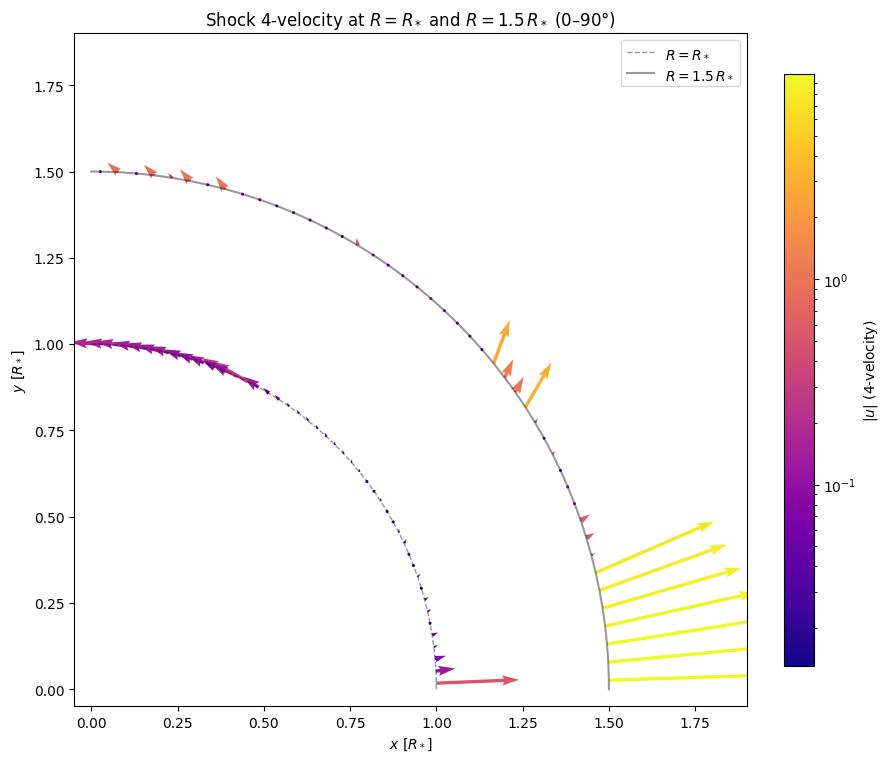

In [27]:
import matplotlib.colors as mcolors

def boundary_arrival_rows(r_tol=0.05, vr_min=0.01):
    """Full shock row (including vr, v_tang) at first R=1.5 boundary arrival per angle."""
    near = (
        fronts[
            (np.abs(fronts['r_shock'] - 1.5) < r_tol) &
            (fronts['vr'] > vr_min)
        ]
        .reset_index()
        .sort_values('time')
    )
    return near.groupby('angle_deg').first().reset_index()

# --- Surface arrival (R=1) ---
arr_surf = surface_arrival_rows().sort_values('angle_deg').reset_index(drop=True)
q_surf = arr_surf[(arr_surf['angle_deg'] >= 0) & (arr_surf['angle_deg'] <= 90)].copy()
phi_surf = np.deg2rad(q_surf['angle_deg'].values)
x_surf = np.cos(phi_surf)
y_surf = np.sin(phi_surf)
vr_s  = q_surf['vr'].values
vt_s  = q_surf['v_tang'].values
vx_s  = vr_s * np.cos(phi_surf) - vt_s * np.sin(phi_surf)
vy_s  = vr_s * np.sin(phi_surf) + vt_s * np.cos(phi_surf)
spd_s = np.sqrt(vx_s**2 + vy_s**2)

# --- Boundary arrival (R=1.5) ---
arr = boundary_arrival_rows().sort_values('angle_deg').reset_index(drop=True)
q = arr[(arr['angle_deg'] >= 0) & (arr['angle_deg'] <= 90)].copy()
phi_q = np.deg2rad(q['angle_deg'].values)
x_pos = 1.5 * np.cos(phi_q)
y_pos = 1.5 * np.sin(phi_q)
vr  = q['vr'].values
vt  = q['v_tang'].values
vx  = vr * np.cos(phi_q) - vt * np.sin(phi_q)
vy  = vr * np.sin(phi_q) + vt * np.cos(phi_q)
spd = np.sqrt(vx**2 + vy**2)

# Shared log-scale norm spanning both datasets
spd_min = min(spd_s[spd_s > 0].min(), spd[spd > 0].min())
spd_max = max(spd_s.max(), spd.max())
norm = mcolors.LogNorm(vmin=spd_min, vmax=spd_max)

# Separate arrow scales so both sets are visually legible
arrow_scale_s = 0.12 / spd_s.max() if spd_s.max() > 0 else 1.0
arrow_scale_b = 0.12 / spd.max()   if spd.max()   > 0 else 1.0

theta_arc = np.linspace(0, np.pi/2, 300)

fig, ax = plt.subplots(figsize=(9, 9))
ax.plot(np.cos(theta_arc), np.sin(theta_arc),
        'k--', lw=1, alpha=0.4, label=r'$R = R_*$')
ax.plot(1.5*np.cos(theta_arc), 1.5*np.sin(theta_arc),
        'k-', lw=1.5, alpha=0.4, label=r'$R = 1.5\,R_*$')

# Surface arrows (R=1)
ax.quiver(
    x_surf, y_surf,
    vx_s * arrow_scale_s, vy_s * arrow_scale_s,
    spd_s, cmap='plasma', norm=norm,
    angles='xy', scale_units='xy', scale=0.5,
    width=0.005
)

# Boundary arrows (R=1.5)
qv = ax.quiver(
    x_pos, y_pos,
    vx * arrow_scale_b, vy * arrow_scale_b,
    spd, cmap='plasma', norm=norm,
    angles='xy', scale_units='xy', scale=0.25,
    width=0.005
)

plt.colorbar(qv, ax=ax, label=r'$|u|\ \mathrm{(4\text{-}velocity)}$', fraction=0.04)

ax.set_xlim(-0.05, 1.9)
ax.set_ylim(-0.05, 1.9)
ax.set_aspect('equal')
ax.set_xlabel(r'$x\ [R_*]$')
ax.set_ylabel(r'$y\ [R_*]$')
ax.set_title(r'Shock 4-velocity at $R = R_*$ and $R = 1.5\,R_*$ ($0$–$90°$)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Video of the whole thing

In [ ]:
from pathlib import Path
ts = yt.load('/scratch/aripoll/athena_out/outputs/jet_blast.out1.*.athdf')
nx, ny = ts[0].domain_dimensions[0], ts[0].domain_dimensions[1]
frames_dir = Path('/scratch/aripoll/athena_out/frames')
frames_dir.mkdir(parents=True, exist_ok=True)

for i, ds in enumerate(ts[800:1100], start=800):
    r_shock_entropy = []  # list of lists: 1 or more radii per theta

    for theta_val in theta_vals:
        ray = ds.ortho_ray(0, (theta_val, z_val))

        df_entr = ray.to_dataframe([('index', 'r'), ('gas', 'entropy')])
        df_entr = df_entr.sort_values('r').reset_index(drop=True)

        if len(df_entr) < 2:
            r_shock_entropy.append([np.nan])
            continue

        # Shock has hit the surface: outer boundary entropy is still unshocked
        if np.log10(df_entr['entropy'].iloc[-1]) < 5:
            r_shock_entropy.append([1.5])
            # print(f"Shock at surface for theta={theta_val:.3f} rad")
            continue

        dlogS_dr = np.gradient(np.log10(df_entr['entropy']), df_entr['r'])
        abs_grad = np.abs(dlogS_dr)

        peaks, _ = find_peaks(abs_grad, height= 100, distance = 10)
        radii = [float(df_entr['r'].iloc[i]) for i in peaks if df_entr['r'].iloc[i] > 0.2]

        if radii:
            # print(f"Shock fronts at theta={theta_val:.3f} rad: {', '.join(f'{r:.3f}' for r in radii)} R_*")
            r_shock_entropy.append(radii)
        else:
            r_shock_entropy.append([np.nan])
        # fig, ax = plt.subplots()
        # ax.plot(df_entr['r'], abs_grad, label='Entropy')
        # for r in radii:
        #     ax.axvline(r, color='r', linestyle='--', label=f'shock r={r:.3f}')
        # ax.set_xlabel(r"$r \ [R_*]$")
        # ax.set_ylabel(r"Entropy $\mathcal{S}$")
        # ax.set_title(rf"Entropy at $\theta = {theta_val*180/np.pi:.3f}$°, $t = {float(ds.current_time):.2f}\ R_*/c$") 
        # ax.legend()
        # plt.show()

    # Flatten for polar plot: duplicate theta for entries with two fronts
    plot_theta = [th for th, rs in zip(theta_vals, r_shock_entropy) for _ in rs]
    plot_r     = [r  for rs in r_shock_entropy for r in rs]

    plt.figure(figsize=(20, 20))
    plt.polar(plot_theta, plot_r, marker='o', color='g', linestyle='none')
    plt.title(rf"Shock Radius from Entropy Gradient at $t = {float(ds.current_time):.2f}\ R_*/c$")
    plt.savefig(frames_dir / f"frame_{i:04d}.png", dpi=100, bbox_inches='tight')
    plt.close()

In [ ]:
#Now make a video using ffmpeg starting from the first frame frame_1400.png to frame_1499.png
frames_dir = Path('/scratch/aripoll/athena_out/frames')
frames_dir.mkdir(parents=True, exist_ok=True)
import subprocess
subprocess.run(['ffmpeg', '-y', '-framerate', '10', '-start_number', '800', '-i', str(frames_dir / 'frame_%04d.png'), '-c:v', 'libx264', '-pix_fmt', 'yuv420p', '-vf', 'pad=ceil(iw/2)*2:ceil(ih/2)*2', 'shock_evolution.mp4'], check=True)

from IPython.display import Video, display
display(Video('shock_evolution.mp4', embed=True))